# 🏏 Virat Kohli Career Analytics: Data Cleaning & ETL Pipeline
**Objective:** Load raw datasets, perform data cleaning, handle missing values, engineer new performance metrics, and export processed datasets for SQL and Power BI ingestion.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for EDA plots
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("Environment setup completed successfully!")

Environment setup completed successfully!


## Step 1: Data Loading & Initial Inspection
Load raw datasets:
1. `virat_milestones_summary_final_2026.csv`
2. `virat_international_yearwise_summary_final_2026.csv`

In [7]:
# Load CSV files
df_milestones = pd.read_csv('virat_milestones_summary_final_2026.csv')
df_yearly = pd.read_csv('virat_international_yearwise_summary_final_2026.csv')

print("--- Milestones Dataset Schema & Shape ---")
print(df_milestones.info())
display(df_milestones.head(3))

print("\n--- Yearwise Performance Dataset Schema & Shape ---")
print(df_yearly.info())
display(df_yearly.head(3))

--- Milestones Dataset Schema & Shape ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Player             10 non-null     object
 1   Career_Type        10 non-null     object
 2   Milestone          10 non-null     object
 3   Format             10 non-null     object
 4   Year               10 non-null     int64 
 5   Opponent_or_Event  10 non-null     object
 6   Venue              10 non-null     object
dtypes: int64(1), object(6)
memory usage: 692.0+ bytes
None


,Player,Career_Type,Milestone,Format,Year,Opponent_or_Event,Venue
0,Virat Kohli,International,ODI debut,ODI,2008,vs Sri Lanka,Dambulla
1,Virat Kohli,International,1st ODI century,ODI,2009,vs Sri Lanka,Kolkata
2,Virat Kohli,International,1st Test century,Test,2012,vs Australia,Adelaide



--- Yearwise Performance Dataset Schema & Shape ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Player         48 non-null     object 
 1   Format         48 non-null     object 
 2   Year           48 non-null     int64  
 3   Matches        48 non-null     int64  
 4   Innings        48 non-null     int64  
 5   Runs           48 non-null     int64  
 6   Average        48 non-null     float64
 7   Strike_Rate    48 non-null     float64
 8   Fifties        48 non-null     int64  
 9   Hundreds       48 non-null     int64  
 10  Highest_Score  48 non-null     int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 4.3+ KB
None


,Player,Format,Year,Matches,Innings,Runs,Average,Strike_Rate,Fifties,Hundreds,Highest_Score
0,Virat Kohli,ODI,2008,5,5,159,31.8,66.0,1,0,54
1,Virat Kohli,ODI,2009,10,10,325,36.1,73.5,2,1,107
2,Virat Kohli,ODI,2010,25,24,995,47.4,82.0,7,3,118


## Step 2: Data Cleaning & Validation
- Trim whitespace from string columns.
- Parse `Highest_Score` to extract numeric values and create a boolean `Is_Not_Out` indicator.
- Convert numeric columns (`Matches`, `Innings`, `Runs`, `Fifties`, `Hundreds`, `Average`, `Strike_Rate`) to proper data types.

In [10]:
# 1. Trim leading/trailing whitespace in string columns
str_cols_m = df_milestones.select_dtypes(include='object').columns
df_milestones[str_cols_m] = df_milestones[str_cols_m].apply(lambda x: x.str.strip())

str_cols_y = df_yearly.select_dtypes(include='object').columns
df_yearly[str_cols_y] = df_yearly[str_cols_y].apply(lambda x: x.str.strip())

# 2. Process Highest_Score (e.g., '183' vs '254*')
df_yearly['Is_Not_Out'] = df_yearly['Highest_Score'].astype(str).str.contains(r'\*', regex=True)
df_yearly['Highest_Score_Clean'] = (
    df_yearly['Highest_Score']
    .astype(str)
    .str.replace('*', '', regex=False)
    .apply(pd.to_numeric, errors='coerce')
    .fillna(0)
    .astype(int)
)

# 3. Clean and convert numeric types
int_cols = ['Matches', 'Innings', 'Runs', 'Fifties', 'Hundreds']
for col in int_cols:
    df_yearly[col] = pd.to_numeric(df_yearly[col], errors='coerce').fillna(0).astype(int)

df_yearly['Average'] = pd.to_numeric(df_yearly['Average'], errors='coerce').fillna(0.0)
df_yearly['Strike_Rate'] = pd.to_numeric(df_yearly['Strike_Rate'], errors='coerce').fillna(0.0)

print("Data cleaning phase completed!")
display(df_yearly[['Year', 'Format', 'Highest_Score', 'Highest_Score_Clean', 'Is_Not_Out']].head())

Data cleaning phase completed!


,Year,Format,Highest_Score,Highest_Score_Clean,Is_Not_Out
0,2008,ODI,54,54,False
1,2009,ODI,107,107,False
2,2010,ODI,118,118,False
3,2011,ODI,117,117,False
4,2012,ODI,183,183,False


## Step 3: Feature Engineering
Calculate key analytical ratios and metrics:
1. **Conversion Rate (%):** Rate of converting 50s into 100s.
2. **Runs per Innings:** Average run productivity per match inning.
3. **Career Era Classification:** Segmenting career years into *Early Career (2008–2012)*, *Peak Dominance (2013–2019)*, and *Resurgence (2020–2026)*.

In [13]:
# 1. Calculate 50-to-100 Conversion Rate (%)
df_yearly['Conversion_Rate_%'] = np.where(
    (df_yearly['Fifties'] + df_yearly['Hundreds']) > 0,
    np.round((df_yearly['Hundreds'] / (df_yearly['Fifties'] + df_yearly['Hundreds'])) * 100, 2),
    0.0
)

# 2. Runs Per Innings
df_yearly['Runs_Per_Innings'] = np.where(
    df_yearly['Innings'] > 0,
    np.round(df_yearly['Runs'] / df_yearly['Innings'], 2),
    0.0
)

# 3. Career Era Tagging Function
def assign_era(year):
    if year <= 2012:
        return 'Early Career (2008–2012)'
    elif year <= 2019:
        return 'Peak / Dominance Era (2013–2019)'
    else:
        return 'Resurgence Era (2020–2026)'

df_yearly['Career_Era'] = df_yearly['Year'].apply(assign_era)

print("Feature engineering completed!")
display(df_yearly[['Year', 'Format', 'Runs', 'Conversion_Rate_%', 'Career_Era']].head())

Feature engineering completed!


,Year,Format,Runs,Conversion_Rate_%,Career_Era
0,2008,ODI,159,0.00,Early Career (2008–2012)
1,2009,ODI,325,33.33,Early Career (2008–2012)
2,2010,ODI,995,30.00,Early Career (2008–2012)
3,2011,ODI,1381,33.33,Early Career (2008–2012)
4,2012,ODI,1026,50.00,Early Career (2008–2012)


## Step 4: Exploratory Data Analysis & Visualizations
Generate aggregated statistical summaries and visual trends across formats and career eras.

--- Format Performance Aggregation ---


,Format,Total_Matches,Total_Innings,Total_Runs,Total_Centuries,Total_Fifties,Career_Avg
0,ODI,311,305,14797,54,77,48.51
1,T20I,125,131,4188,1,38,31.97
2,Test,123,201,9230,30,31,45.92


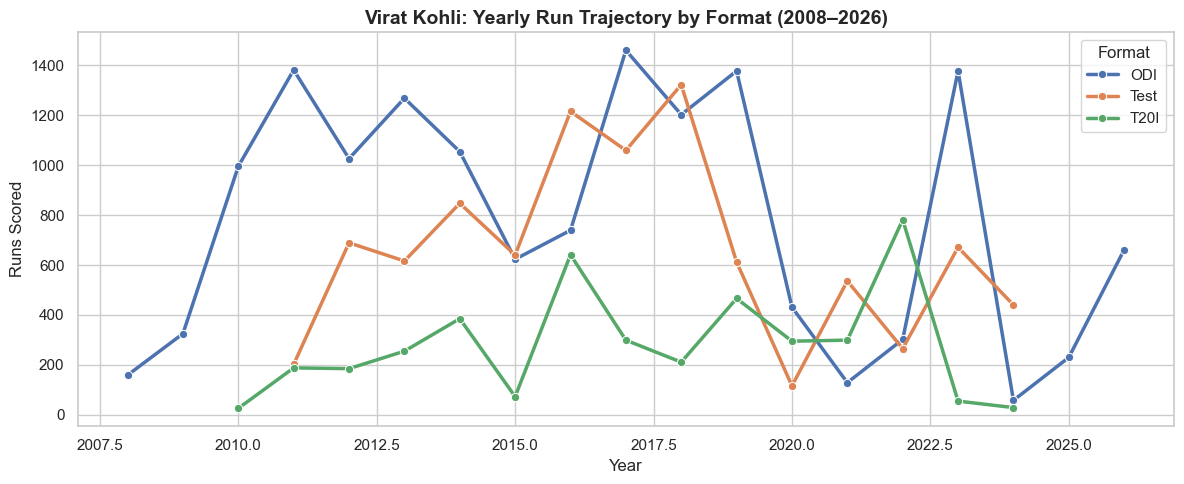

In [16]:
# Aggregated performance by format
format_summary = df_yearly.groupby('Format').agg(
    Total_Matches=('Matches', 'sum'),
    Total_Innings=('Innings', 'sum'),
    Total_Runs=('Runs', 'sum'),
    Total_Centuries=('Hundreds', 'sum'),
    Total_Fifties=('Fifties', 'sum'),
    Career_Avg=('Runs', lambda x: round(x.sum() / df_yearly.loc[x.index, 'Innings'].sum(), 2))
).reset_index()

print("--- Format Performance Aggregation ---")
display(format_summary)

# Plot: Yearly Run Trajectory by Format
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_yearly, x='Year', y='Runs', hue='Format', marker='o', linewidth=2.5)
plt.title("Virat Kohli: Yearly Run Trajectory by Format (2008–2026)", fontsize=14, fontweight='bold')
plt.ylabel("Runs Scored")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

## Step 5: Export Processed Datasets
Export the transformed and cleaned datasets as CSV files ready for **SQL Database Insertion** and **Power BI Integration**.

In [19]:
# Export cleaned CSV files
df_yearly.to_csv('cleaned_virat_international_yearwise_2026.csv', index=False)
df_milestones.to_csv('cleaned_virat_milestones_2026.csv', index=False)

print("✅ Files exported successfully:")
print(" 1. cleaned_virat_international_yearwise_2026.csv")
print(" 2. cleaned_virat_milestones_2026.csv")

✅ Files exported successfully:
 1. cleaned_virat_international_yearwise_2026.csv
 2. cleaned_virat_milestones_2026.csv
